In [14]:
import numpy as np
import matplotlib.pyplot as plt
import json, itertools, os


def get_best_relative_loss(filename, specimen, loadstep):
    with open(filename) as f:
        data = json.load(f)
        loss = data['losses']
    best_loss = np.array(loss)
    strain_meas = np.load(f'rebar_strains/s{specimen}_ls{loadstep}_combined.npy', allow_pickle=True) * 1e-6
    strain_meas_sq = strain_meas ** 2.0
    factor = np.sum(0.5 * strain_meas_sq * 1.0e20)
    return best_loss / factor

specimens = [str(i) for i in np.arange(4)+1]
loadsteps = [str(i) for i in np.arange(5)+1]
loadsteps = ['1', '2', '6']
freeze_rebars = ['0', '1']
opt_slices = ['0', '1']

combinations = list(itertools.product(specimens, loadsteps, freeze_rebars, opt_slices))
for specimen, loadstep, freeze_rebar, opt_slice in combinations:
    # filename = f"results/3d_prism_s{specimen}_ls{loadstep}_freeze_{bool(int(freeze_rebar))}_slice_{bool(int(opt_slice))}.json"

    exp_name = f"3d_prism_s{specimen}_ls{loadstep}_freeze_{bool(int(freeze_rebar))}_slice_{bool(int(opt_slice))}"
result_filename = f"figures/{exp_name}_slices.png"

    


filenames = os.listdir('results')
filenames_searched = [s.startswith(exp_name) for s in filenames]
match_sum = sum(filenames_searched)
np.argwhere(filenames_searched)
filenames[np.argwhere(filenames_searched)[0][0]]

'3d_prism_s4_ls6_freeze_True_slice_True_lr_100000000_steps_100.json'

In [20]:
import os

filenames = os.listdir('figures')
for filename in filenames:
    if '_100.' in filename or '_100_' in filename:
        os.remove('figures/'+filename)
# filenames

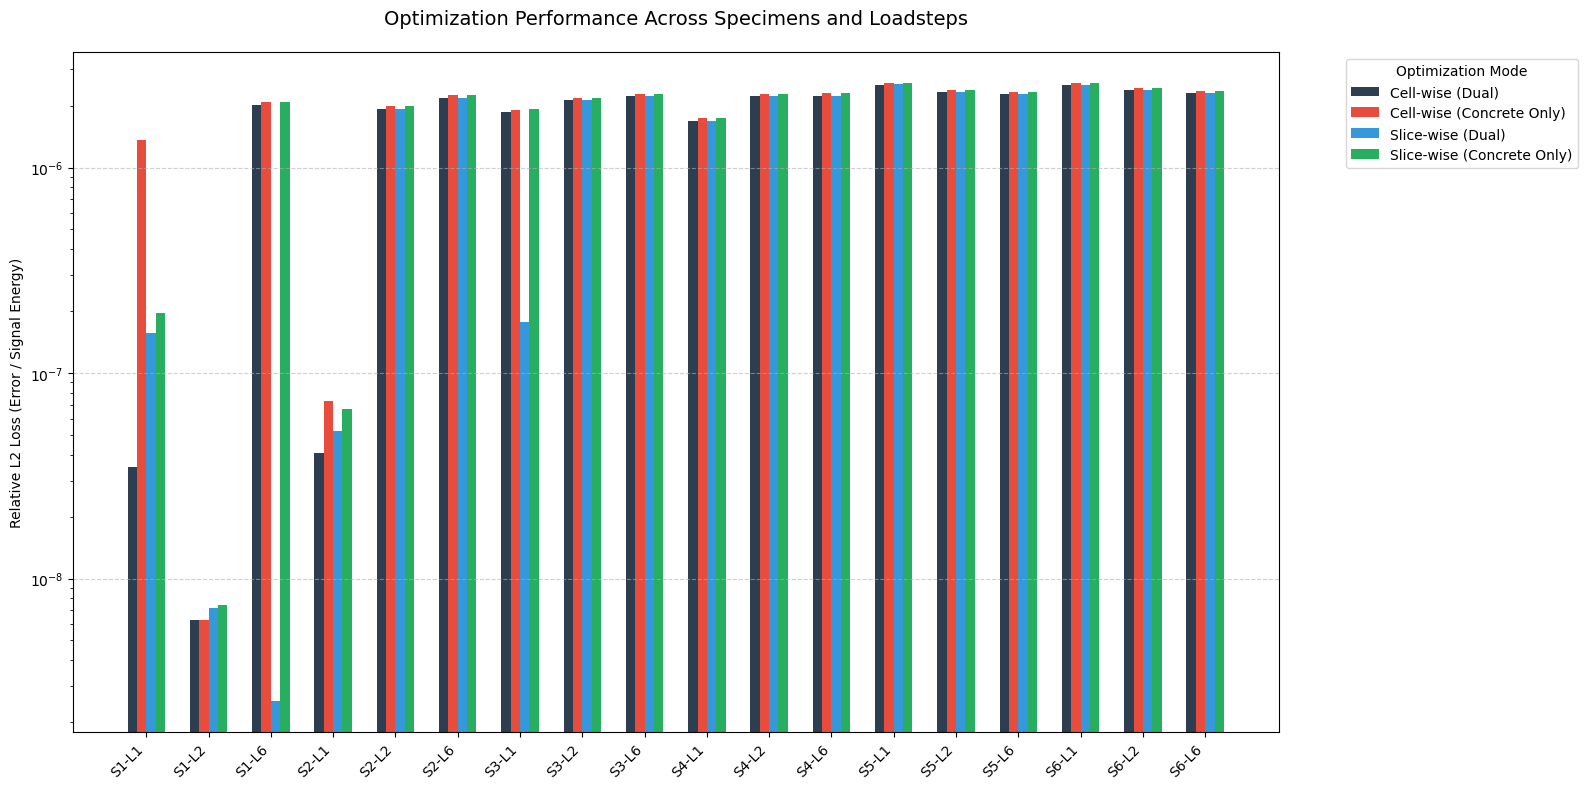

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import json, itertools, os

def get_best_relative_loss(filename, specimen, loadstep):
    try:
        with open(filename) as f:
            data = json.load(f)
            # Take the minimum loss achieved during the run
            loss = np.min(data['losses'])
        
        strain_meas = np.load(f'rebar_strains/s{specimen}_ls{loadstep}_combined.npy', allow_pickle=True) * 1e-6
        # Factor must match your Warp integrand exactly
        factor = np.sum(0.5 * (strain_meas ** 2.0) * 1.0e20)
        return loss / factor
    except FileNotFoundError:
        return None

filenames = os.listdir('results')
specimens = [str(i) for i in np.arange(6)+1]
loadsteps = [str(i) for i in np.arange(5)+1]
loadsteps = ['1', '2', '6']
configs = [
    # (freeze_rebar, opt_slice, label, color)
    ('0', '0', 'Cell-wise (Dual)', '#2c3e50'),
    ('1', '0', 'Cell-wise (Concrete Only)', '#e74c3c'),
    ('0', '1', 'Slice-wise (Dual)', '#3498db'),
    ('1', '1', 'Slice-wise (Concrete Only)', '#27ae60')
]

# Plotting setup
fig, ax = plt.subplots(figsize=(16, 8))
x_labels = []
x_ticks = []

bar_width = 0.18
group_spacing = 1.2

# Iterate through specimens and loadsteps to create X-axis groups
for i, (spec, ls) in enumerate(itertools.product(specimens, loadsteps)):
    base_x = i * group_spacing
    x_labels.append(f"S{spec}-L{ls}")
    x_ticks.append(base_x + (bar_width * 1.5))
    
    for j, (frz, slc, label, col) in enumerate(configs):
        fname = f"results/3d_prism_s{spec}_ls{ls}_freeze_{bool(int(frz))}_slice_{bool(int(slc))}.json"
        exp_name = f"3d_prism_s{spec}_ls{ls}_freeze_{bool(int(frz))}_slice_{bool(int(slc))}"
        filenames_searched = [s.startswith(exp_name) for s in filenames]
        fname = filenames[np.argwhere(filenames_searched)[0][0]]
        rel_loss = get_best_relative_loss("results/"+fname, spec, ls)
        if rel_loss is not None:
            # Add a bar for each optimization configuration
            rect = ax.bar(base_x + j * bar_width, rel_loss, bar_width, 
                          color=col, label=label if i == 0 else "")

# Styling
ax.set_ylabel('Relative L2 Loss (Error / Signal Energy)')
ax.set_title('Optimization Performance Across Specimens and Loadsteps', fontsize=14, pad=20)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yscale('log') # Use log scale because losses vary significantly
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(title="Optimization Mode", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

'100000000.0'